# Project 7: Gibbs Sampling
Sophia Klymchuk and Devin Zhang

Read the paper on Gibbs sampling, implement it using a software package such as PyMC, Stan, PyStan. Note that Gibbs sampling itself doesn't cooperate with some of these packages for this particular scenario. Use any sampling method available to do the inference.

Stretch goal 5 points: Implement Gibbs sampling by hand as shown in the paper

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy import stats

## Data Generation
Generate the synthetic data ($N=50$, change-point at $n=26$).

<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-3523678668.py:26: SyntaxWarning: invalid escape sequence '\l'
  color='r', linestyle='--', label='True Rate ($\lambda$)')


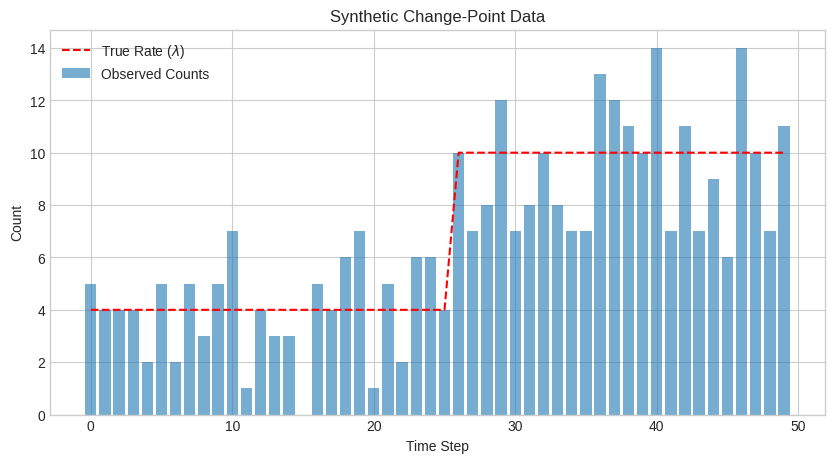

In [ ]:
# Set styling
plt.style.use('seaborn-v0_8-whitegrid')

# Parameters from the paper [cite: 101, 103]
N = 50  # Number of datapoints
a = 2  # Alpha for Gamma prior
b = 1  # Beta for Gamma prior

# True generative parameters (similar to Figure 1 in the paper)
true_n = 26        # Change-point
true_lambda1 = 4.0 # Initial rate
true_lambda2 = 10.0 # Rate after change

# Generate Data
np.random.seed(42)
# Indices 0 to true_n-1 (first 26 points) get lambda1
data_pre = np.random.poisson(true_lambda1, size=true_n)
# Indices true_n to N-1 (remaining 24 points) get lambda2
data_post = np.random.poisson(true_lambda2, size=N - true_n)
data = np.concatenate([data_pre, data_post])

# Visualization
plt.figure(figsize=(10, 5))
plt.bar(range(N), data, alpha=0.6, label='Observed Counts')
plt.plot(range(N), [true_lambda1]*true_n + [true_lambda2]*(N-true_n),
         color='r', linestyle='--', label='True Rate ($\lambda$)')
plt.xlabel("Time Step")
plt.ylabel("Count")
plt.title("Synthetic Change-Point Data")
plt.legend()
plt.show()

## Implementation with PyMC
PyMC's default sampler (NUTS) requires continuous gradients, but $n$ is a discrete latent variable. PyMC handles this by assigning a Metropolis stepper to the discrete variable $n$ and NUTS to the continuous variables $\lambda_1, \lambda_2$.


Output()

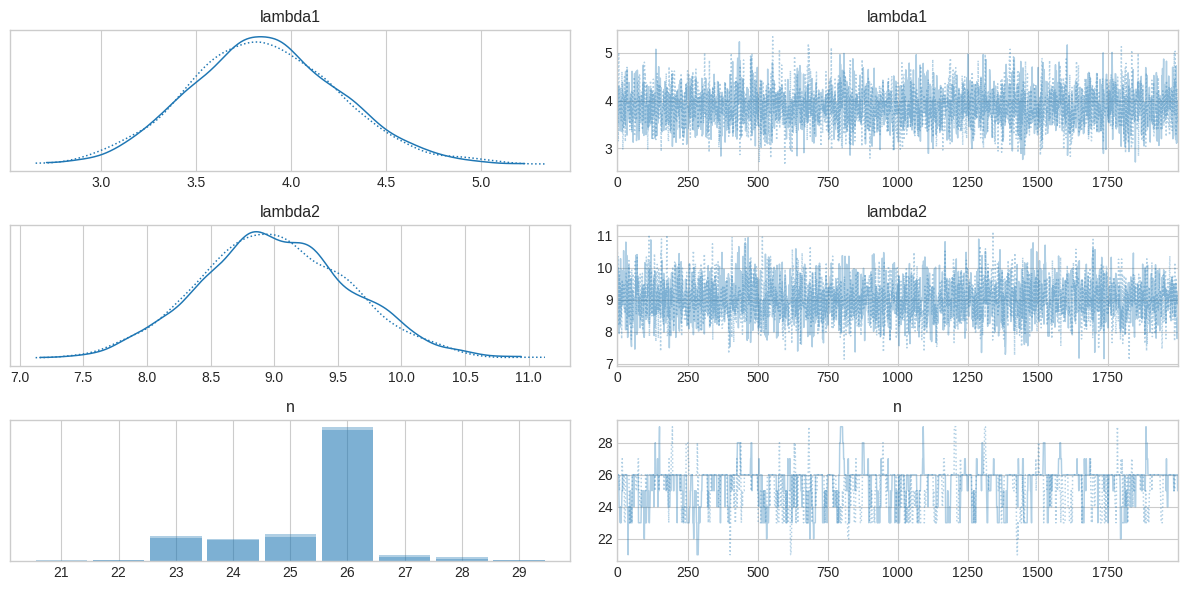

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
lambda1   3.863  0.398   3.135    4.624      0.008    0.007    2743.0   
lambda2   9.011  0.609   7.846   10.135      0.013    0.009    2159.0   
n        25.385  1.201  23.000   26.000      0.067    0.041     310.0   

         ess_tail  r_hat  
lambda1    2389.0   1.00  
lambda2    2943.0   1.00  
n           648.0   1.01  


In [ ]:
with pm.Model() as model:
    # Priors
    # Note: PyMC's Gamma uses alpha (shape) and beta (rate) just like the paper
    lambda1 = pm.Gamma("lambda1", alpha=a, beta=b)  # Gamma prior for initial rate
    lambda2 = pm.Gamma("lambda2", alpha=a, beta=b)  # Gamma prior for rate after change

    # Discrete Uniform prior for the change-point n
    # We use 0 to N-1 for array indexing convenience
    n = pm.DiscreteUniform("n", lower=0, upper=N-1) # Uniform prior for change point
    # n is constant over all indices but changes per iteration.

    # Define the rate vector based on n
    # Ideally we select lambda1 if i < n, else lambda2.
    # We use pm.math.switch for a symbolic switch
    idx = np.arange(N)  # Creates a index array [0, 1, ..., N-1]
    lambda_v = pm.math.switch(idx < n, lambda1, lambda2)  # We can't use an if statement because they are random variables. So we use pm.math.switch.

    # Likelihood
    # For each guess, calculate the likelihood of observed data.
    obs = pm.Poisson("obs", mu=lambda_v, observed=data)   # Calculates the product of all N likelihoods.

    # Inference
    # PyMC will automatically assign Metropolis to 'n' and NUTS to lambdas
    trace = pm.sample(2000, tune=1000, return_inferencedata=True, random_seed=42)
    # The first 1000 samples are burned, the later 2000 are kept.
    # This means 3000 different guesses of the values of n, lambda1 and lambda2ve

# Visualize Results
az.plot_trace(trace)
plt.tight_layout()
plt.show()

# Summary
print(az.summary(trace, var_names=["lambda1", "lambda2", "n"]))

## Implementation by Hand (Stretch Goal)

Conditionals: <br>
$\lambda_1$: Sample from $Gamma(a + \sum_{i=1}^n x_i, n + b)$ <br>
$\lambda_2$: Sample from $Gamma(a + \sum_{i=n+1}^N x_i, (N-n) + b)$<br>
$n$: The posterior for $n$ is proportional to the likelihood given $\lambda_1, \lambda_2$. We calculate $p(n | \dots)$ for every possible $n$ and sample from that categorical distribution

Note: Numpy's random.gamma(shape, scale) uses scale ($1/\beta$). The paper uses rate ($\beta$). We must convert: scale = 1/beta.

<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:80: SyntaxWarning: invalid escape sequence '\l'
<>:82: SyntaxWarning: invalid escape sequence '\l'
<>:87: SyntaxWarning: invalid escape sequence '\l'
<>:89: SyntaxWarning: invalid escape sequence '\l'
<>:94: SyntaxWarning: invalid escape sequence '\l'
<>:96: SyntaxWarning: invalid escape sequence '\l'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:80: SyntaxWarning: invalid escape sequence '\l'
<>:82: SyntaxWarning: invalid escape sequence '\l'
<>:87: SyntaxWarning: invalid escape sequence '\l'
<>:89: SyntaxWarning: invalid escape sequence '\l'
<>:94: SyntaxWarning: invalid escape sequence '\l'
<>:96: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-695897614.py:79: SyntaxWarning: invalid escape sequence '\l'
  axes[1].plot(manual_trace['lambda1'], color='green', alpha=0.6, label='$\lambda_1$ Trace')
/tmp/ipython-input-695897614.py:80: SyntaxWarning: invalid escape sequence '\l'
  axes[1].plot(manual_trace['lamb

Running Manual Gibbs Sampler...


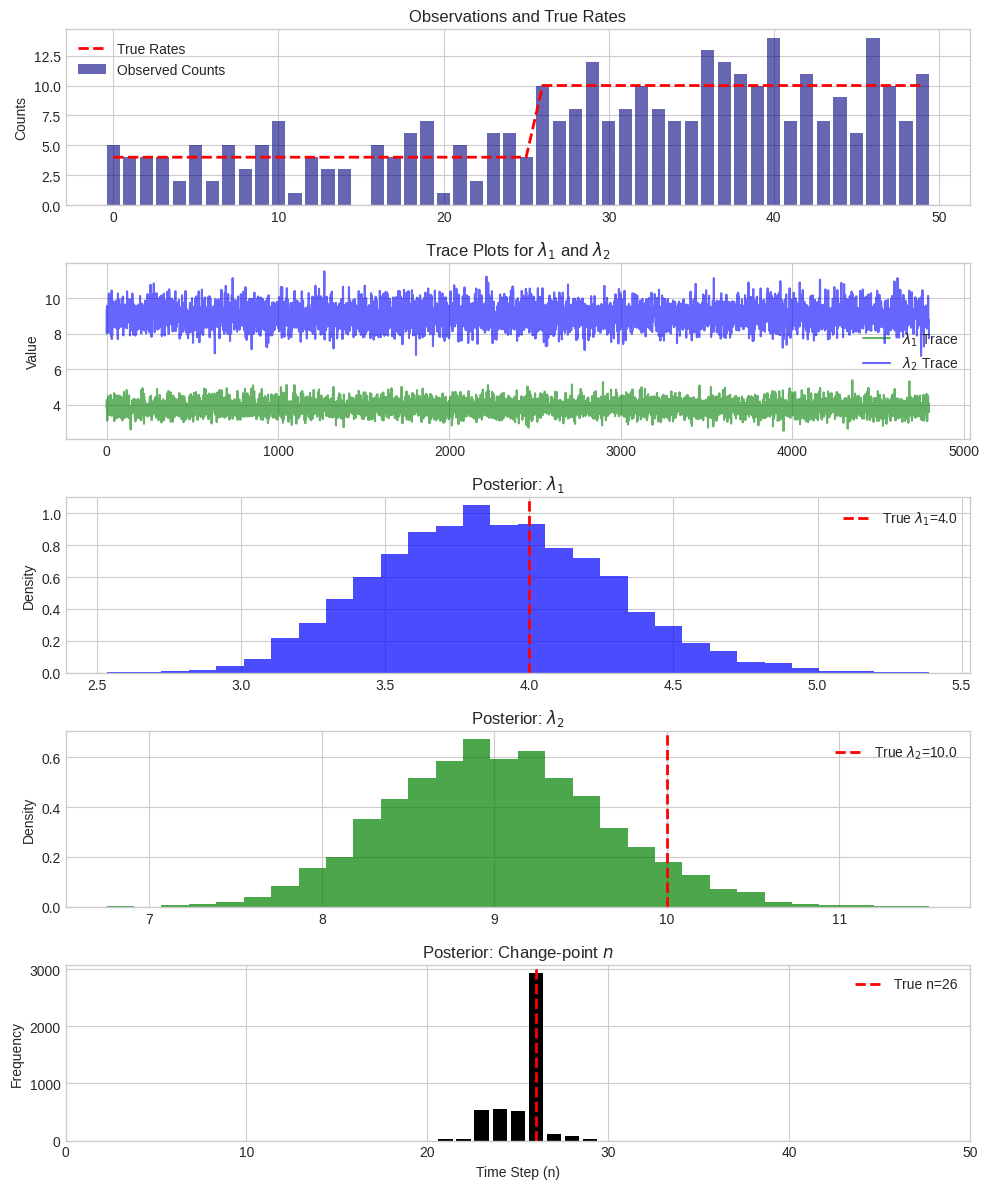

--- Manual Gibbs Sampler Results ---
Mean n: 25.35 (True: 26)
Mean lambda1: 3.87 (True: 4.0)
Mean lambda2: 9.02 (True: 10.0)


In [ ]:
def manual_gibbs_sampler(data, iterations=5000, burn_in=200):
    N = len(data)

    # Initialize
    n_curr = np.random.randint(1, N)  # prior for n, change point
    lambda1_curr = np.random.gamma(a, 1/b)  # gamma prior for before change
    lambda2_curr = np.random.gamma(a, 1/b)  # gamma prior for after change

    # Store traces
    trace = {"n": [], "lambda1": [], "lambda2": []}

    for i in range(iterations):
        # 1. Sample Lambda 1 (Gamma Posterior)
        # Using data points BEFORE the change-point n_curr
        # data[:n_curr] gives indices 0 to n_curr-1
        data_1 = data[:n_curr]
        alpha_1 = a + np.sum(data_1)
        beta_1 = len(data_1) + b # (n + b) in paper
        lambda1_curr = np.random.gamma(alpha_1, 1/beta_1) # Scale = 1/beta
        # Poisson-Gamma conjugate pair. Poisson summarizes to sum and len, gamma accepts these.

        # 2. Sample Lambda 2 (Gamma Posterior)
        # Using data points AFTER the change-point
        data_2 = data[n_curr:]
        alpha_2 = a + np.sum(data_2)
        beta_2 = len(data_2) + b # (N - n + b) in paper
        lambda2_curr = np.random.gamma(alpha_2, 1/beta_2)

        # 3. Sample n (Multinomial/Categorical)
        # Calculate log-prob for every possible change point k
        # We compute unnormalized log-posterior
        possible_ns = np.arange(1, N) # Possible split points
        log_probs = []

        for k in possible_ns:
            # Split data
            d1 = data[:k]
            d2 = data[k:]

            # Log Likelihood: sum(x * log(lam) - lam)
            # Constant terms like log(x!) cancel out in normalization
            ll_1 = np.sum(d1) * np.log(lambda1_curr) - k * lambda1_curr
            ll_2 = np.sum(d2) * np.log(lambda2_curr) - (N - k) * lambda2_curr

            log_probs.append(ll_1 + ll_2)

        # Normalize in log-space to avoid underflow
        log_probs = np.array(log_probs)
        log_probs = log_probs - np.max(log_probs) # Numerical stability
        probs = np.exp(log_probs)
        probs = probs / np.sum(probs)

        # Sample new n
        n_curr = np.random.choice(possible_ns, p=probs)

        # Store after burn-in
        if i >= burn_in:
            trace["n"].append(n_curr)
            trace["lambda1"].append(lambda1_curr)
            trace["lambda2"].append(lambda2_curr)

    return trace

# Run the manual sampler
print("Running Manual Gibbs Sampler...")
manual_trace = manual_gibbs_sampler(data)

# --- 4. Plotting to Match the Paper ---
fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=False)

# Row 1: The Data
axes[0].bar(range(N), data, alpha=0.6, color='navy', label='Observed Counts')
axes[0].plot(range(N), [true_lambda1]*true_n + [true_lambda2]*(N-true_n),
             'r--', label='True Rates', linewidth=2)
axes[0].set_ylabel("Counts")
axes[0].set_title("Observations and True Rates")
axes[0].legend()

# Row 2: Trace Plot for Lambdas
axes[1].plot(manual_trace['lambda1'], color='green', alpha=0.6, label='$\lambda_1$ Trace')
axes[1].plot(manual_trace['lambda2'], color='blue', alpha=0.6, label='$\lambda_2$ Trace')
axes[1].set_ylabel("Value")
axes[1].set_title("Trace Plots for $\lambda_1$ and $\lambda_2$")
axes[1].legend()

# Row 3: Histogram Lambda 1
axes[2].hist(manual_trace['lambda1'], bins=30, density=True, color='blue', alpha=0.7)
axes[2].axvline(true_lambda1, color='red', linestyle='--', linewidth=2, label=f'True $\lambda_1$={true_lambda1}')
axes[2].set_ylabel("Density")
axes[2].set_title("Posterior: $\lambda_1$")
axes[2].legend()

# Row 4: Histogram Lambda 2
axes[3].hist(manual_trace['lambda2'], bins=30, density=True, color='green', alpha=0.7)
axes[3].axvline(true_lambda2, color='red', linestyle='--', linewidth=2, label=f'True $\lambda_2$={true_lambda2}')
axes[3].set_ylabel("Density")
axes[3].set_title("Posterior: $\lambda_2$")
axes[3].legend()

# Row 5: Histogram n
# Using a bar chart for discrete n is often cleaner than hist
n_counts = np.bincount(manual_trace['n'], minlength=N)
axes[4].bar(range(len(n_counts)), n_counts, color='black')
axes[4].set_xlim(0, N)
axes[4].axvline(true_n, color='red', linestyle='--', linewidth=2, label=f'True n={true_n}')
axes[4].set_ylabel("Frequency")
axes[4].set_xlabel("Time Step (n)")
axes[4].set_title("Posterior: Change-point $n$")
axes[4].legend()

plt.tight_layout()
plt.show()

# Verification Stats
print("--- Manual Gibbs Sampler Results ---")
print(f"Mean n: {np.mean(manual_trace['n']):.2f} (True: {true_n})")
print(f"Mean lambda1: {np.mean(manual_trace['lambda1']):.2f} (True: {true_lambda1})")
print(f"Mean lambda2: {np.mean(manual_trace['lambda2']):.2f} (True: {true_lambda2})")